In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0217 15:46:56.857827 140586839807808 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'

dir_model_v1 = root_dir_models+'v_test/loss/'  # bnn test: 2 denseFlipout after convolutions

In [4]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

In [5]:
model_bnn = model.create_model_prob_flipout_peak(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0217 15:46:58.147593 140586839807808 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0217 15:46:58.566733 140586839807808 deprecation.py:323] From ../../scripts/tools_for_VAE/tools_for_VAE/ktied_distribution.py:37: Layer.add_variable (from tensorflow.python.keras.engine.base_layer) is deprecated and will be removed in a future version.
Instructions for updating:
Please use `layer.add_weight` method instead.
W0217 15:46:58.575640 140586839807808 module_wrapper.py:138] From ../../scripts/tools_for_VAE/tools_for_VAE/ktied_distribution.py:45: The name tf.keras.initializers.TruncatedNormal is deprecated. Please use tf.compat.v1.keras.initi

[8192, 256]
Tensor("dense_flipout/Size:0", shape=(), dtype=int32)
[256, 5]
Tensor("dense_flipout_1/Size:0", shape=(), dtype=int32)


W0217 15:46:58.780290 140586839807808 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


In [6]:
latest = tf.train.latest_checkpoint(dir_model_v1)
model_bnn.load_weights(latest)

In [11]:
model_bnn.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 59, 59, 6)    24          input_1[0][0]                    
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
conv2d_2 (Conv2D)               (None, 59, 59, 32)   1760        batch_normalization[0][0]        
______________________________________________________________________________________________

In [7]:
np.shape(model_bnn.get_weights())

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


(62,)

In [10]:
model_bnn.get_weights()[0]

array([0.17970496, 0.8737897 , 1.0912952 , 1.0526458 , 0.6875118 ,
       0.38930607], dtype=float32)

In [12]:
for i in range (len(model_bnn.get_weights())):
    print(model_bnn.get_weights()[i].shape)

(6,)
(6,)
(6,)
(6,)
(3, 3, 6, 32)
(32,)
(3, 3, 6, 32)
(32,)
(59, 59, 32)
(59, 59, 32)
(3, 3, 32, 32)
(32,)
(3, 3, 32, 32)
(32,)
(30, 30, 32)
(30, 30, 32)
(3, 3, 32, 64)
(64,)
(3, 3, 32, 64)
(64,)
(30, 30, 64)
(30, 30, 64)
(3, 3, 64, 64)
(64,)
(3, 3, 64, 64)
(64,)
(15, 15, 64)
(15, 15, 64)
(3, 3, 64, 128)
(128,)
(3, 3, 64, 128)
(128,)
(15, 15, 128)
(15, 15, 128)
(3, 3, 128, 128)
(128,)
(3, 3, 128, 128)
(128,)
(8, 8, 128)
(8, 8, 128)
(3, 3, 128, 256)
(256,)
(3, 3, 128, 256)
(256,)
(8, 8, 256)
(8, 8, 256)
(3, 3, 256, 256)
(256,)
(3, 3, 256, 256)
(256,)
(4, 4, 256)
(4, 4, 256)
(8192,)
(8192, 256)
(8192, 2)
(256, 2)
(256,)
(256,)
(256, 5)
(256, 2)
(5, 2)
(5,)


In [15]:
print(model_bnn.get_weights()[58].shape)

(256, 5)


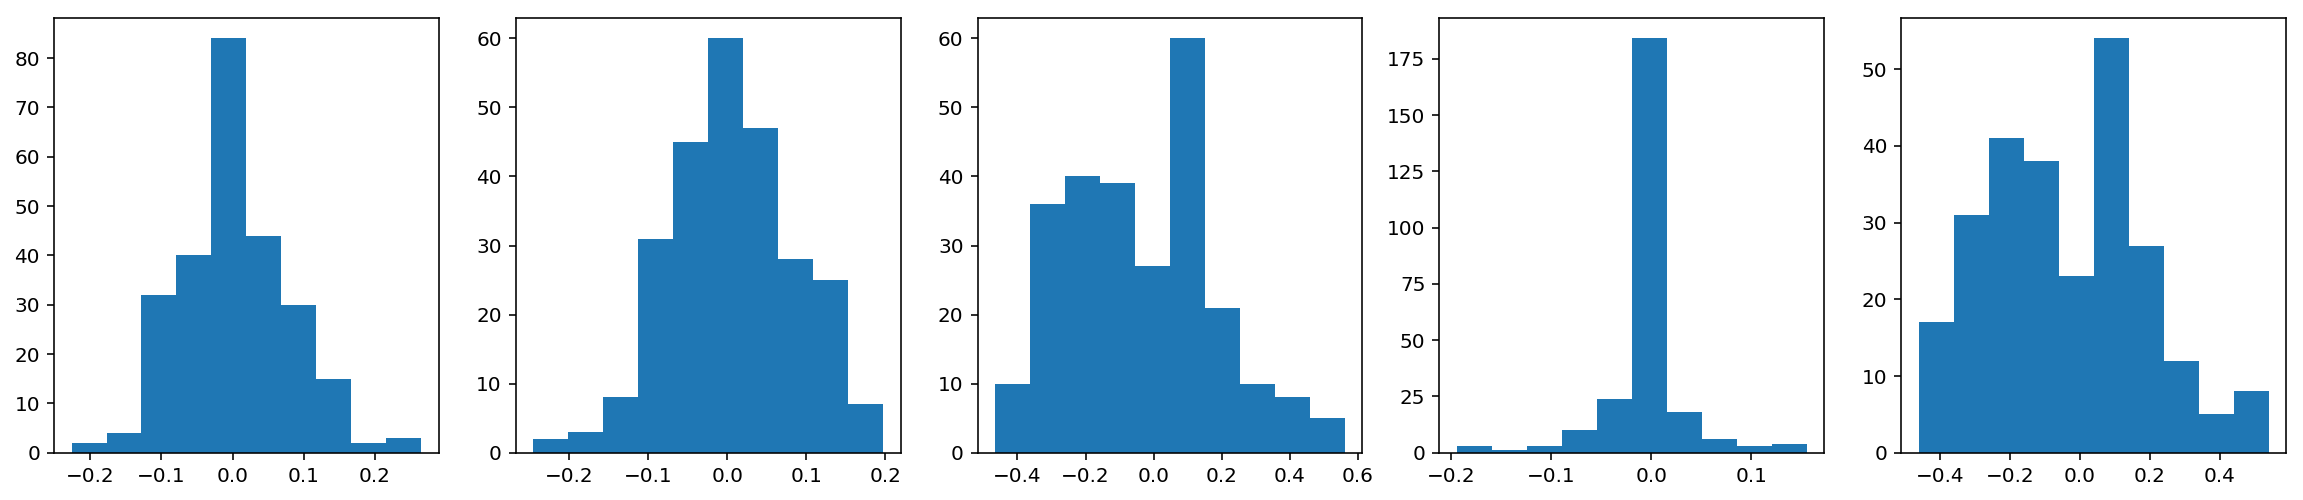

In [23]:
fig, axes = plt.subplots(1,5,figsize = (20,4))
for i in range (5):
    _ = axes[i].hist(model_bnn.get_weights()[58][:,i])

from http://www.moxleystratton.com/tensorflow-visualizing-weights/

and https://www.tensorflow.org/tutorials/quickstart/beginner

In [10]:
import tensorflow.compat.v1 as tf1
import tensorflow.keras as keras
import tensorflow_probability as tfp
from tensorflow_probability.python.layers import util as tfp_layers_util
from tensorboard.plugins.hparams import api as hp

In [11]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

print("Number of original training examples:", len(x_train))
print("Number of original test examples:", len(x_test))


Number of original training examples: 60000
Number of original test examples: 10000


In [12]:
x_train.shape

(60000, 28, 28)

In [13]:
# Weights initialization for posteriors
def get_posterior_fn():
    return tfp_layers_util.default_mean_field_normal_fn(
      loc_initializer=tf1.initializers.he_normal(), 
      untransformed_scale_initializer=tf1.initializers.random_normal(
          mean=-9, stddev=0.1)
      )
# kernel divergence weight in loss
#HP_kl = hp.HParam('kl', hp.RealInterval(0., 1.))

tfd = tfp.distributions
kernel_divergence_fn=(lambda q, p, ignore: tfd.kl_divergence(q, p) / (60000))



model = keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
      #tf.keras.layers.Dense(128, activation='relu'),

     tfp.layers.DenseFlipout(32, 
                             kernel_posterior_fn=get_posterior_fn(), 
                             kernel_divergence_fn = kernel_divergence_fn, 
                             bias_posterior_fn = get_posterior_fn(),
                             bias_divergence_fn = kernel_divergence_fn,
                             activation='relu'),
    tfp.layers.DenseFlipout(32, 
                             kernel_posterior_fn=get_posterior_fn(), 
                             kernel_divergence_fn = kernel_divergence_fn, 
                             bias_posterior_fn = get_posterior_fn(),
                             bias_divergence_fn = kernel_divergence_fn,
                             activation='relu'),
    tfp.layers.DenseFlipout(32, 
                             kernel_posterior_fn=get_posterior_fn(), 
                             kernel_divergence_fn = kernel_divergence_fn, 
                             bias_posterior_fn = get_posterior_fn(),
                             bias_divergence_fn = kernel_divergence_fn,
                             activation='relu'),
    
    tfp.layers.DenseFlipout(10, 
                             kernel_posterior_fn=get_posterior_fn(), 
                             kernel_divergence_fn = kernel_divergence_fn, 
                             bias_posterior_fn = get_posterior_fn(),
                             bias_divergence_fn = kernel_divergence_fn,
                             activation=None),
    #tf.keras.layers.Dense(1, activation = None),
    #tf.keras.layers.Dense(1, activation = None),
])

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)


learning_rate = 1e-3
model.compile(optimizer=tf.optimizers.Adam(learning_rate=learning_rate) ,
              loss=loss_fn,
              metrics=['accuracy'])


In [14]:
# Records the weights throughout the training process
weights_history = []
biases_history = []
other_history = []
other_2_history = []

weights_sec_history = []
biases_sec_history = []
other_sec_history = []
other_2_sec_history = []

weights_third_history = []
biases_third_history = []
other_third_history = []
other_2_third_history = []

weights_fourth_history = []
biases_fourth_history = []
other_fourth_history = []
other_2_fourth_history = []

# A custom callback
# https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/Callback
class MyCallback(keras.callbacks.Callback):
    def on_batch_end(self, batch, logs):
        weights, _biases, other, other_2, weights_sec, _biases_sec, other_sec, other_2_sec, weights_third, _biases_third, other_third, other_2_third, weights_fourth, _biases_fourth, other_fourth, other_2_fourth= model.get_weights()
        weights = np.mean(K.get_value(weights))
        _biases = np.mean(K.get_value(_biases))
        other = np.mean(K.get_value(other))
        other_2 = np.mean(K.get_value(other_2))
        
        weights_sec = np.mean(K.get_value(weights_sec))
        _biases_sec = np.mean(K.get_value(_biases_sec))
        other_sec = np.mean(K.get_value(other_sec))
        other_2_sec = np.mean(K.get_value(other_2_sec))
        
        weights_third = np.mean(K.get_value(weights_third))
        _biases_third = np.mean(K.get_value(_biases_third))
        other_third = np.mean(K.get_value(other_third))
        other_2_third = np.mean(K.get_value(other_2_third))
        
        weights_fourth = np.mean(K.get_value(weights_fourth))
        _biases_fourth = np.mean(K.get_value(_biases_fourth))
        other_fourth = np.mean(K.get_value(other_fourth))
        other_2_fourth = np.mean(K.get_value(other_2_fourth))
        #w1, w2 = weights
        #b1, b2 = _biases
        #weights = [w1[0], w2[0]]
        #_biases = [b1[0], b2[0]]
        #other = other[0]
        ##weights_sec = weights_sec[0]
        #_biases_sec = _biases_sec[0]
        #other_sec = other_sec[0]
        #print('on_batch_end() model.weights:', weights)
        weights_history.append(weights)
        biases_history.append(_biases)
        other_history.append(other)
        other_2_history.append(other_2)

        weights_sec_history.append(weights_sec)
        biases_sec_history.append(_biases_sec)
        other_sec_history.append(other_sec)
        other_2_sec_history.append(other_2_sec)

        weights_third_history.append(weights_third)
        biases_third_history.append(_biases_third)
        other_third_history.append(other_third)
        other_2_third_history.append(other_2_third)
        
        weights_fourth_history.append(weights_fourth)
        biases_fourth_history.append(_biases_fourth)
        other_fourth_history.append(other_fourth)
        other_2_fourth_history.append(other_2_fourth)
        
callback = MyCallback()

In [15]:
model.fit(x_train, y_train, epochs=2,
          verbose=1, callbacks=[callback])

Train on 60000 samples
Epoch 1/2
60000/60000 [==============================] - 11s 180us/sample - loss: 3.8083 - acc: 0.8985
Epoch 2/2
60000/60000 [==============================] - 10s 169us/sample - loss: 2.8269 - acc: 0.9514


In [16]:
np.shape(model.get_weights())

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


(16,)

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_flipout_2 (DenseFlipou (None, 32)                50240     
_________________________________________________________________
dense_flipout_3 (DenseFlipou (None, 32)                2112      
_________________________________________________________________
dense_flipout_4 (DenseFlipou (None, 32)                2112      
_________________________________________________________________
dense_flipout_5 (DenseFlipou (None, 10)                660       
Total params: 55,124
Trainable params: 55,124
Non-trainable params: 0
_________________________________________________________________


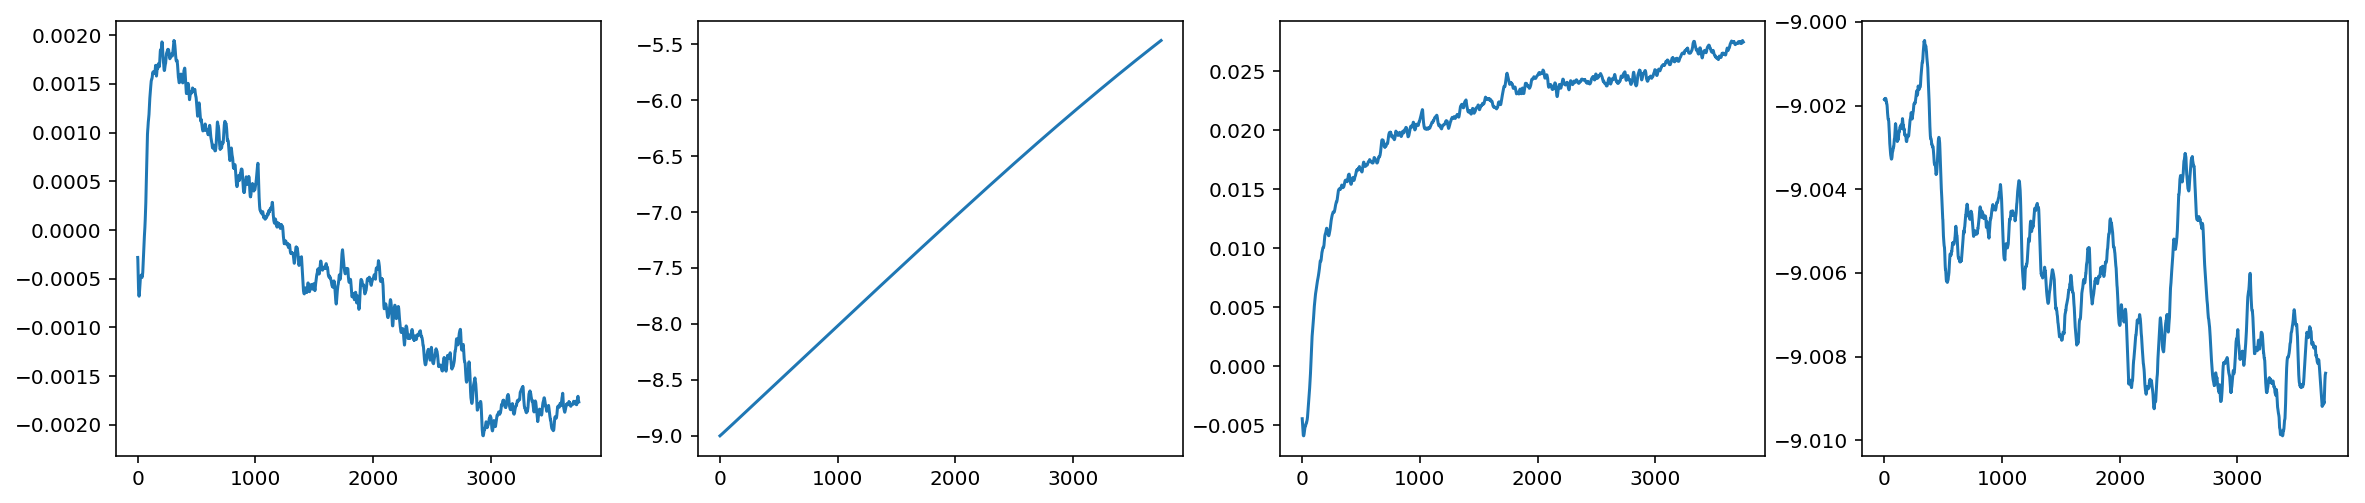

In [18]:
fig, axes = plt.subplots(1,4,figsize = (20,4))

axes[0].plot(weights_history)
axes[1].plot(biases_history)
axes[2].plot(other_history)
axes[3].plot(other_2_history)

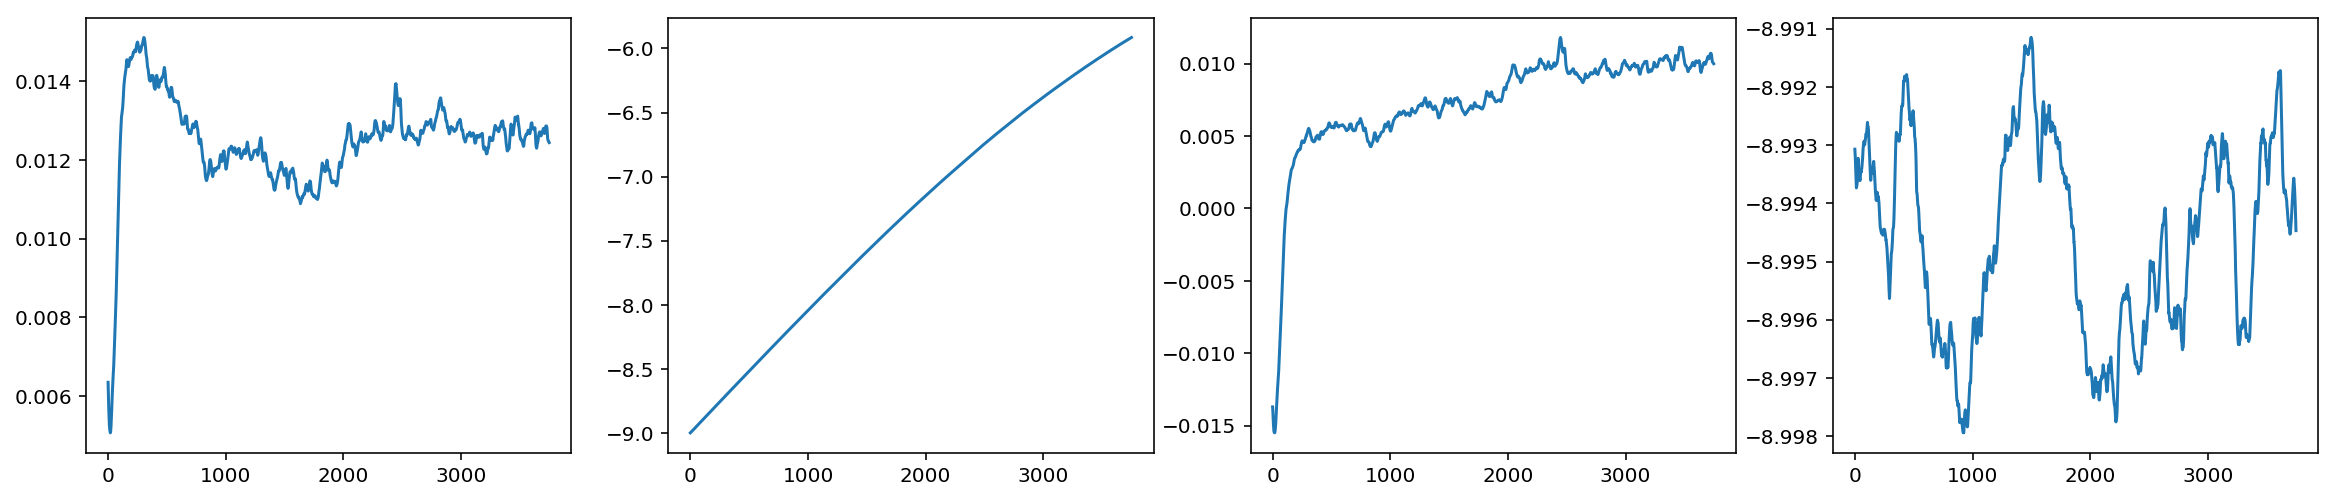

In [19]:
fig, axes = plt.subplots(1,4,figsize = (20,4))

axes[0].plot(weights_sec_history)
axes[1].plot(biases_sec_history)
axes[2].plot(other_sec_history)
axes[3].plot(other_2_sec_history)

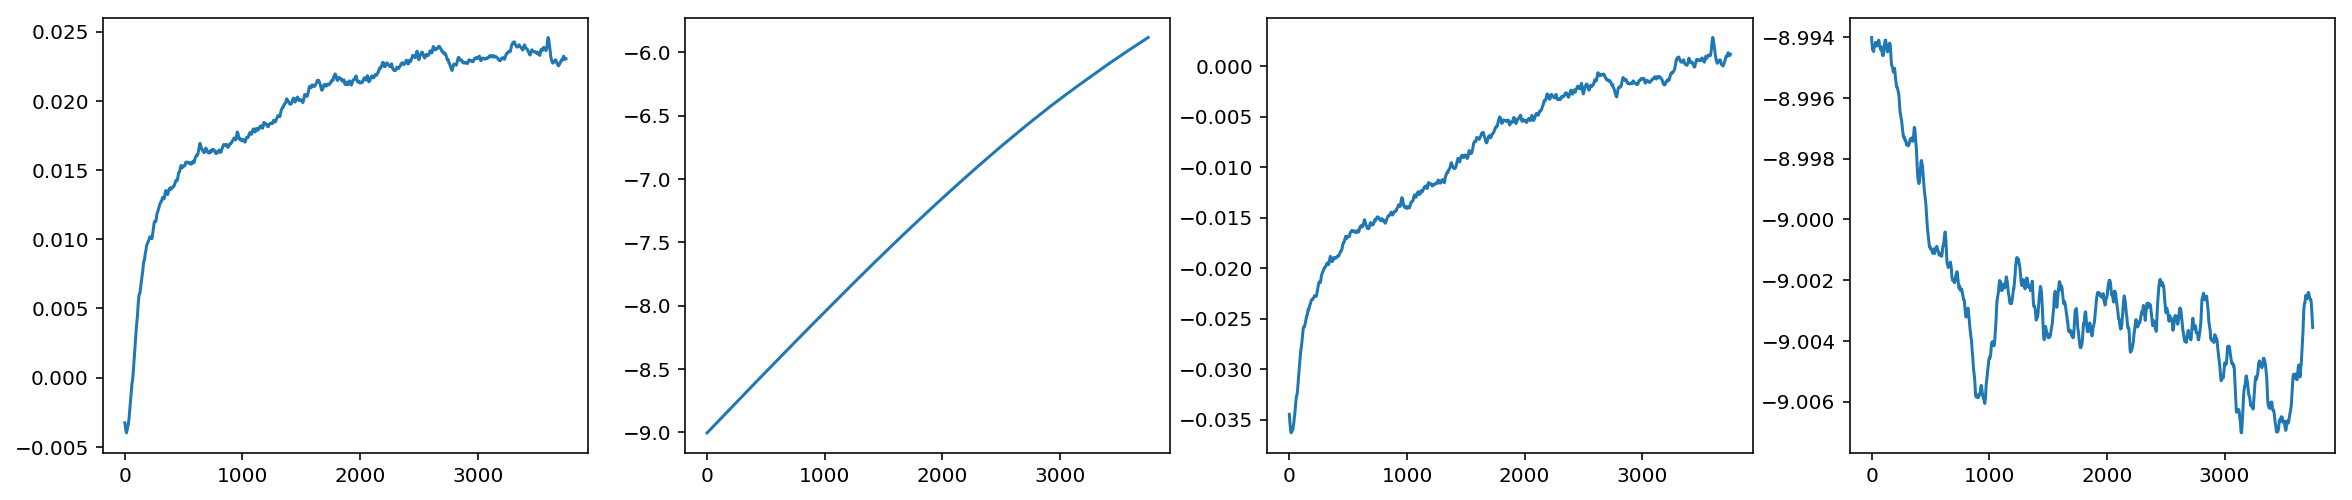

In [20]:
fig, axes = plt.subplots(1,4,figsize = (20,4))

axes[0].plot(weights_third_history)
axes[1].plot(biases_third_history)
axes[2].plot(other_third_history)
axes[3].plot(other_2_third_history)

In [21]:
#test_data = np.random.random((10, 2))
#test_labels = np.array(list(map(tanh, test_data)))

#test_loss, _ = model.evaluate(test_data, test_labels)

In [22]:
out  = model.predict(x_test)

In [23]:
out.shape

(10000, 10)

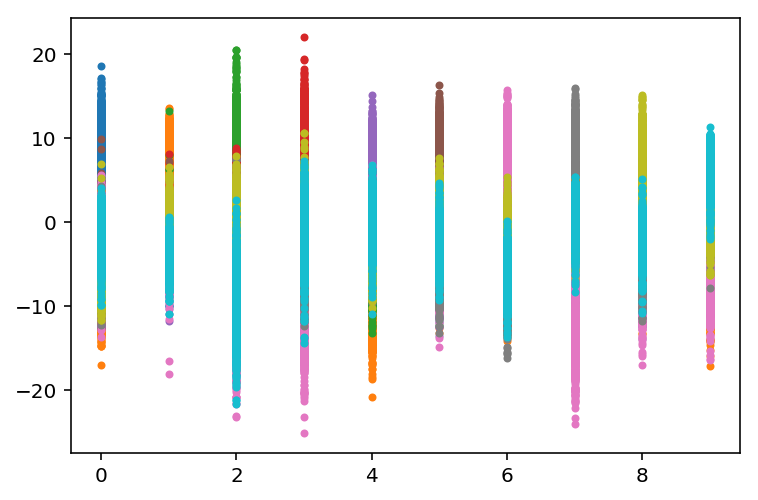

In [24]:
plt.plot(y_test,out, '.')

In [25]:
model.get_weights()

[array([[ 6.6027245e-31, -9.0931365e-32, -3.7666316e-31, ...,
         -5.3931051e-31, -6.9758607e-32,  6.1976576e-31],
        [-5.5865472e-31, -5.3874166e-31,  7.0168389e-31, ...,
          4.7743531e-31,  6.8097427e-31, -2.2982838e-31],
        [ 4.0859464e-31, -6.4309594e-31, -5.5434521e-32, ...,
          7.0022059e-31, -4.2442615e-31,  1.9273528e-31],
        ...,
        [-3.2273254e-31, -1.5091126e-31, -2.5959561e-31, ...,
          9.2281655e-32, -5.1663729e-31, -6.1644146e-31],
        [ 1.8470363e-31, -4.4188431e-31,  2.4334327e-31, ...,
          2.1251051e-32,  3.6912208e-31, -6.6794984e-31],
        [-1.2522662e-31, -4.0660129e-31, -5.6915708e-32, ...,
          1.3255692e-31, -6.6345719e-31, -4.2080746e-31]], dtype=float32),
 array([[-5.248634 , -5.287831 , -5.333968 , ..., -5.329961 , -5.2835307,
         -5.3072243],
        [-5.122673 , -5.2152314, -5.1457987, ..., -5.341411 , -5.2817073,
         -5.4212685],
        [-5.297668 , -5.235715 , -5.049202 , ..., -5.05131

In [26]:
model.get_weights()[0]

array([[ 6.6027245e-31, -9.0931365e-32, -3.7666316e-31, ...,
        -5.3931051e-31, -6.9758607e-32,  6.1976576e-31],
       [-5.5865472e-31, -5.3874166e-31,  7.0168389e-31, ...,
         4.7743531e-31,  6.8097427e-31, -2.2982838e-31],
       [ 4.0859464e-31, -6.4309594e-31, -5.5434521e-32, ...,
         7.0022059e-31, -4.2442615e-31,  1.9273528e-31],
       ...,
       [-3.2273254e-31, -1.5091126e-31, -2.5959561e-31, ...,
         9.2281655e-32, -5.1663729e-31, -6.1644146e-31],
       [ 1.8470363e-31, -4.4188431e-31,  2.4334327e-31, ...,
         2.1251051e-32,  3.6912208e-31, -6.6794984e-31],
       [-1.2522662e-31, -4.0660129e-31, -5.6915708e-32, ...,
         1.3255692e-31, -6.6345719e-31, -4.2080746e-31]], dtype=float32)

In [27]:
model.get_weights()[4]

array([[ 0.73144335, -0.42923838,  0.3300978 , ..., -0.16036986,
         0.51764214, -0.13105391],
       [-0.13889344,  0.17912996, -0.00957685, ...,  0.30198047,
         0.2605278 , -0.12870796],
       [ 0.38388065, -0.17008829, -0.0105808 , ...,  0.34581262,
        -0.10647978, -0.44981316],
       ...,
       [ 0.24872476, -0.1453212 ,  0.616494  , ...,  0.10337857,
        -0.305924  ,  0.08293144],
       [-0.30176324,  0.33930525,  0.19554356, ..., -0.0032356 ,
         0.14476387,  0.18437336],
       [ 0.37562552, -0.10225616,  0.25691256, ...,  0.33168823,
        -0.1845541 ,  0.31364113]], dtype=float32)

In [28]:
model.layers

In [29]:
print('layer 1')
#print(K.get_value(model.layers[0].kernel_posterior.mean()))
#print(K.get_value(tf.nn.softplus(model.layers[0].kernel_posterior.stddev())))

print('layer 2')
print(np.mean(K.get_value(model.layers[1].kernel_posterior.mean())))
print(np.mean(K.get_value(tf.nn.softplus(model.layers[1].kernel_posterior.stddev()))))

print('layer 3')
print(np.mean(K.get_value(model.layers[2].kernel_posterior.mean())))
print(np.mean(K.get_value(tf.nn.softplus(model.layers[2].kernel_posterior.stddev()))))

print('layer 4')
print(np.mean(K.get_value(model.layers[3].kernel_posterior.mean())))
print(np.mean(K.get_value(tf.nn.softplus(model.layers[3].kernel_posterior.stddev()))))

print('layer 5')
print(np.mean(K.get_value(model.layers[3].kernel_posterior.mean())))
print(np.mean(K.get_value(tf.nn.softplus(model.layers[3].kernel_posterior.stddev()))))

layer 1
layer 2
-0.0017641059
0.6953212
layer 3
0.012436974
0.694648
layer 4
0.023061633
0.6946938
layer 5
0.023061633
0.6946938


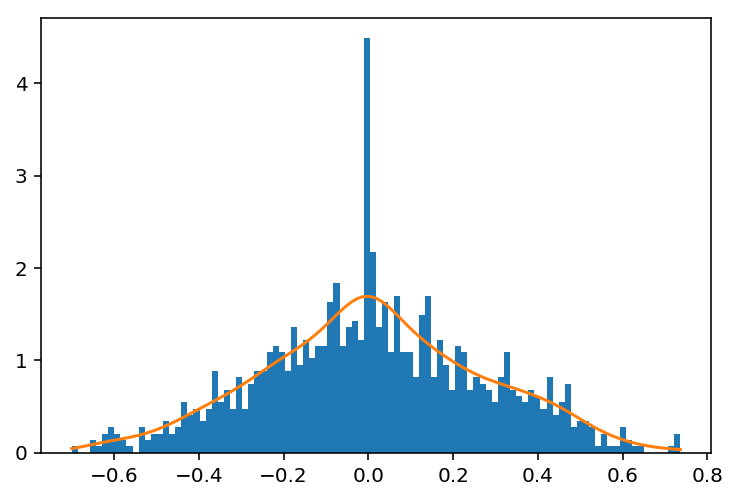

In [43]:
import scipy.stats as stats

density = stats.gaussian_kde(np.reshape(K.get_value(model.layers[2].kernel_posterior.mean()), (K.get_value(model.layers[2].kernel_posterior.mean()).shape[0]*K.get_value(model.layers[2].kernel_posterior.mean()).shape[1])))
n, x, _ = plt.hist(np.reshape(K.get_value(model.layers[2].kernel_posterior.mean()), (K.get_value(model.layers[2].kernel_posterior.mean()).shape[0]*K.get_value(model.layers[2].kernel_posterior.mean()).shape[1])), bins = 100, density = True)
plt.plot(x, density(x))

In [36]:
K.get_value(model.layers[1].kernel_posterior.mean()).shape

(784, 32)

In [31]:
K.get_value(model.layers[2].kernel_posterior.mean()).shape

(32, 32)

In [32]:
K.get_value(model.layers[2].kernel_posterior.stddev()).shape

(32, 32)

In [33]:
K.get_value(model.layers[2].kernel_posterior.mean()[0]).shape

(32,)

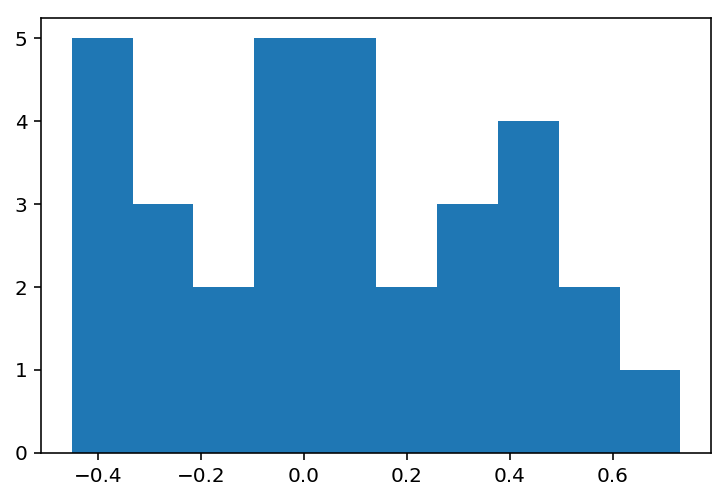

In [35]:
_ = plt.hist(K.get_value(model.layers[2].kernel_posterior.mean()[0]), bins = 10)